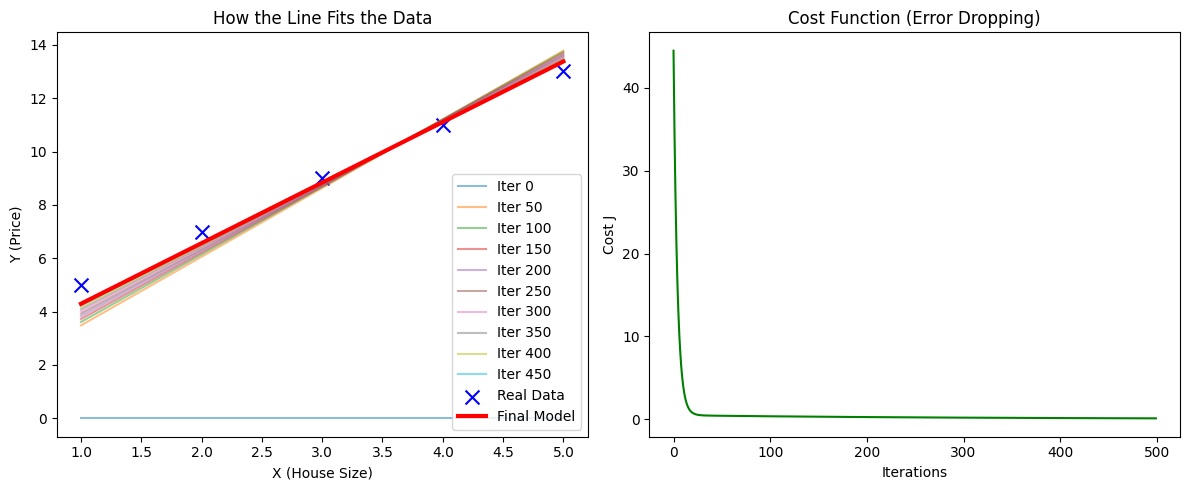

最终预测公式为: y = 2.27x + 2.03


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 9, 11, 13])

# 2. 初始化参数
theta0, theta1 = 0.0, 0.0
alpha = 0.01
iterations = 500
m = len(x)

# 用于记录绘图数据
costs = []
history_theta = []

# 创建画布
plt.figure(figsize=(12, 5))

# 3. 梯度下降循环
for i in range(iterations):
    prediction = theta0 + theta1 * x
    error = prediction - y
    
    # 计算代价 (MSE)
    cost = (1/(2*m)) * np.sum(error**2)
    costs.append(cost)
    
    # 计算梯度
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * x)
    
    # 更新参数
    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1
    
    # 每隔 50 次迭代画一条拟合线
    if i % 50 == 0:
        plt.subplot(1, 2, 1)
        plt.plot(x, prediction, label=f'Iter {i}', alpha=0.5)

# --- 绘图逻辑 ---

# 图 1: 拟合过程
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', marker='x', s=100, label='Real Data')
plt.plot(x, theta0 + theta1 * x, color='red', linewidth=3, label='Final Model')
plt.title('How the Line Fits the Data')
plt.xlabel('X (House Size)')
plt.ylabel('Y (Price)')
plt.legend()

# 图 2: 误差下降曲线 (Learning Curve)
plt.subplot(1, 2, 2)
plt.plot(range(iterations), costs, color='green')

plt.title('Cost Function (Error Dropping)')
plt.xlabel('Iterations')
plt.ylabel('Cost J')

plt.tight_layout()
plt.show()

print(f"最终预测公式为: y = {theta1:.2f}x + {theta0:.2f}")

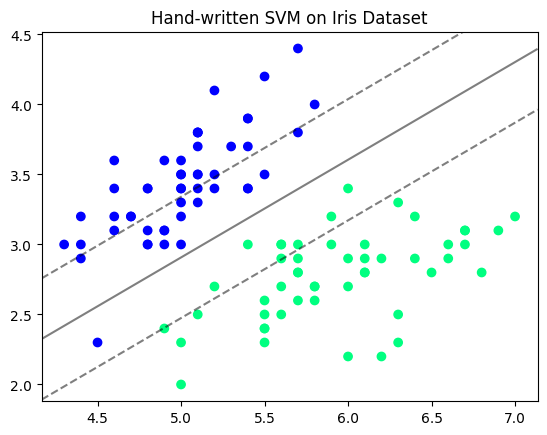

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# 1. 加载数据 (只取前两类，实现二分类)
iris = datasets.load_iris()
X = iris.data[:100, :2] # 取前100个样本，前2个特征（花萼长度、宽度）
y = iris.target[:100]
y = np.where(y == 0, -1, 1) # SVM 标签需要是 -1 和 1

# 2. 定义 SVM 类
class SimpleSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # 核心判断条件: y_i * (w·x_i - b) >= 1
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    # 分类正确，且在间隔外：只更新正则化项
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # 分类错误，或在间隔内：更新正则化项 + 误差项
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

# 3. 训练模型
model = SimpleSVM(n_iters=1000)
model.fit(X, y)

# 4. 可视化结果
def visualize_svm():
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', label='Data Points')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = (np.dot(xy, model.w) - model.b).reshape(XX.shape)
    
    # 绘制决策边界和间隔
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title("Hand-written SVM on Iris Dataset")
    plt.show()

visualize_svm()